In [1]:
import os

import numpy as np

from scripts.data_loader import load_dataframe
from scripts.utils import RF_PARAM, extract_unique_npcis

# source files
BASE_DIR = "data/"
FULL_DATA_SET = "Campaign_data_NBIoT_1_2_3_4_5_6_interpolated_smoothed.mat"
filename = os.path.join(BASE_DIR, FULL_DATA_SET)

# Series of random seeds for reproducability
random_seeds = np.loadtxt('data/random_seeds.csv', dtype=int)

# load the dataframe from saved file or 'raw' matlab file
df = load_dataframe(filename)

Loaded dataframe from .h5 file: data/Campaign_data_NBIoT_1_2_3_4_5_6_interpolated_smoothed.mat_dataframe.h5


## Data preprocessing
1. Clustering the RP's with k-means based on lat,lng coordinates
2. Training a Random Forest classifier using NSINR as the feature to predict the cluster

✅  1/1 runs


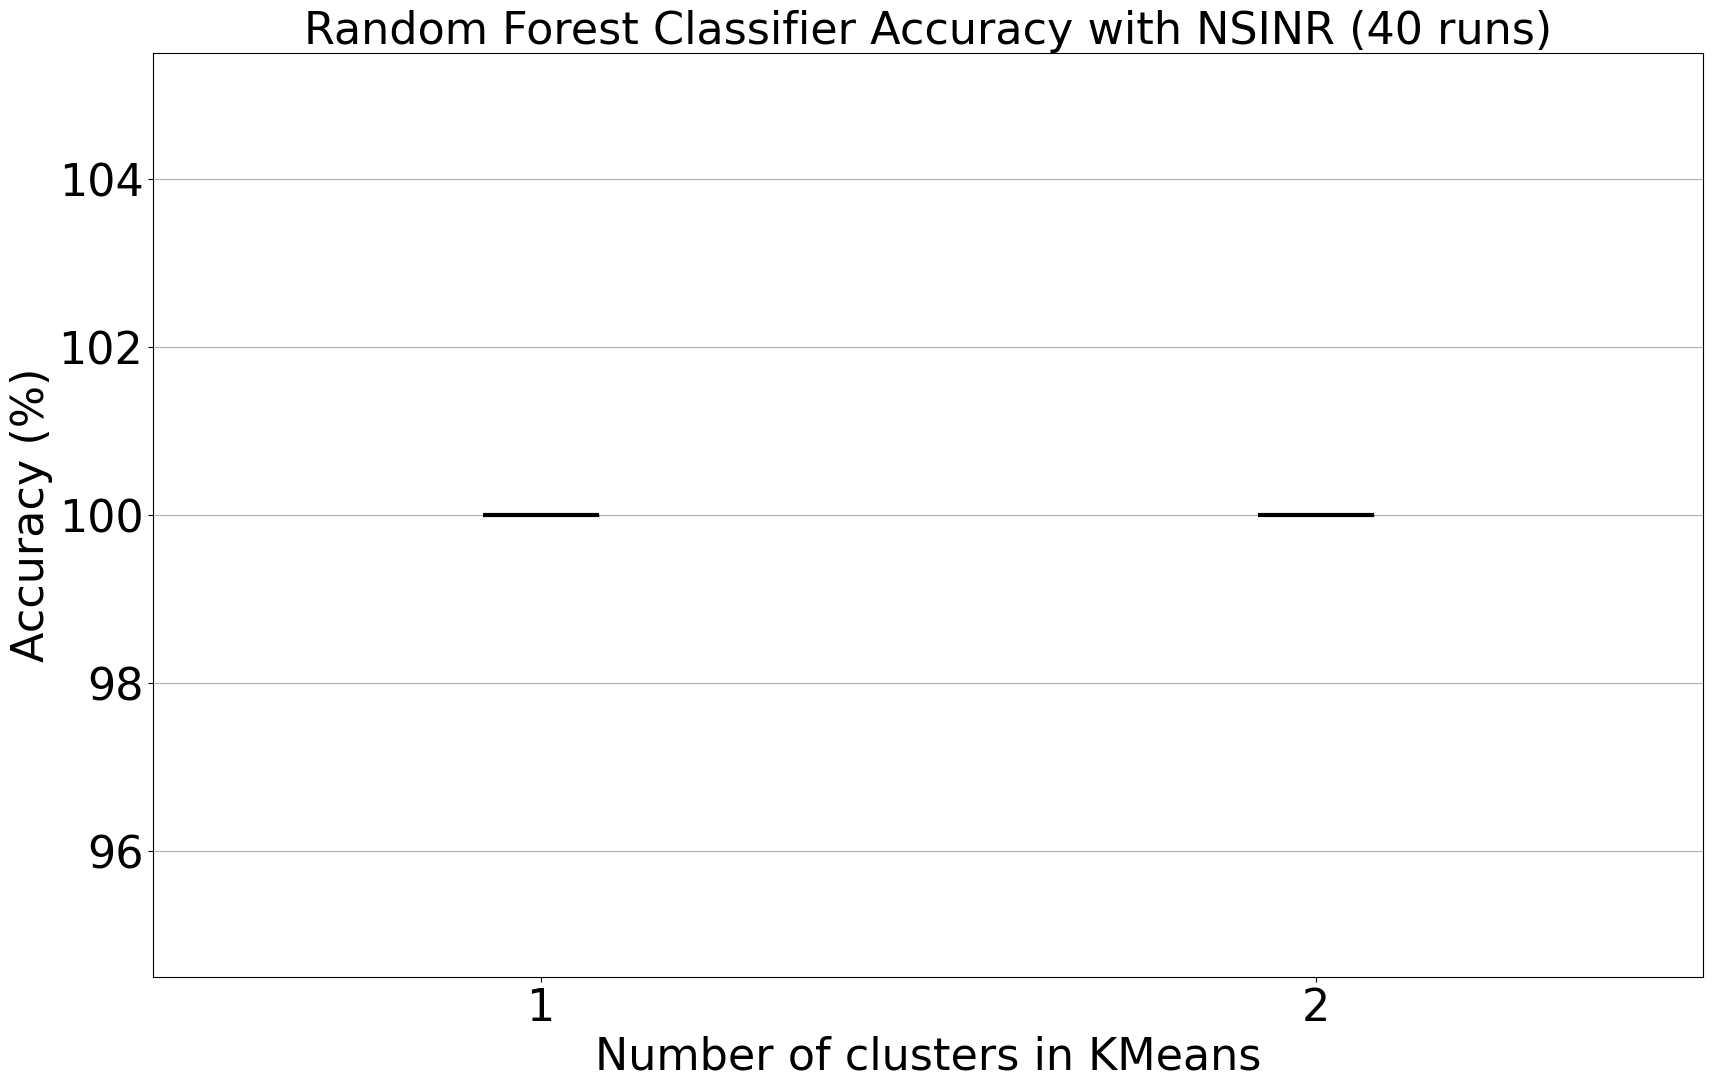

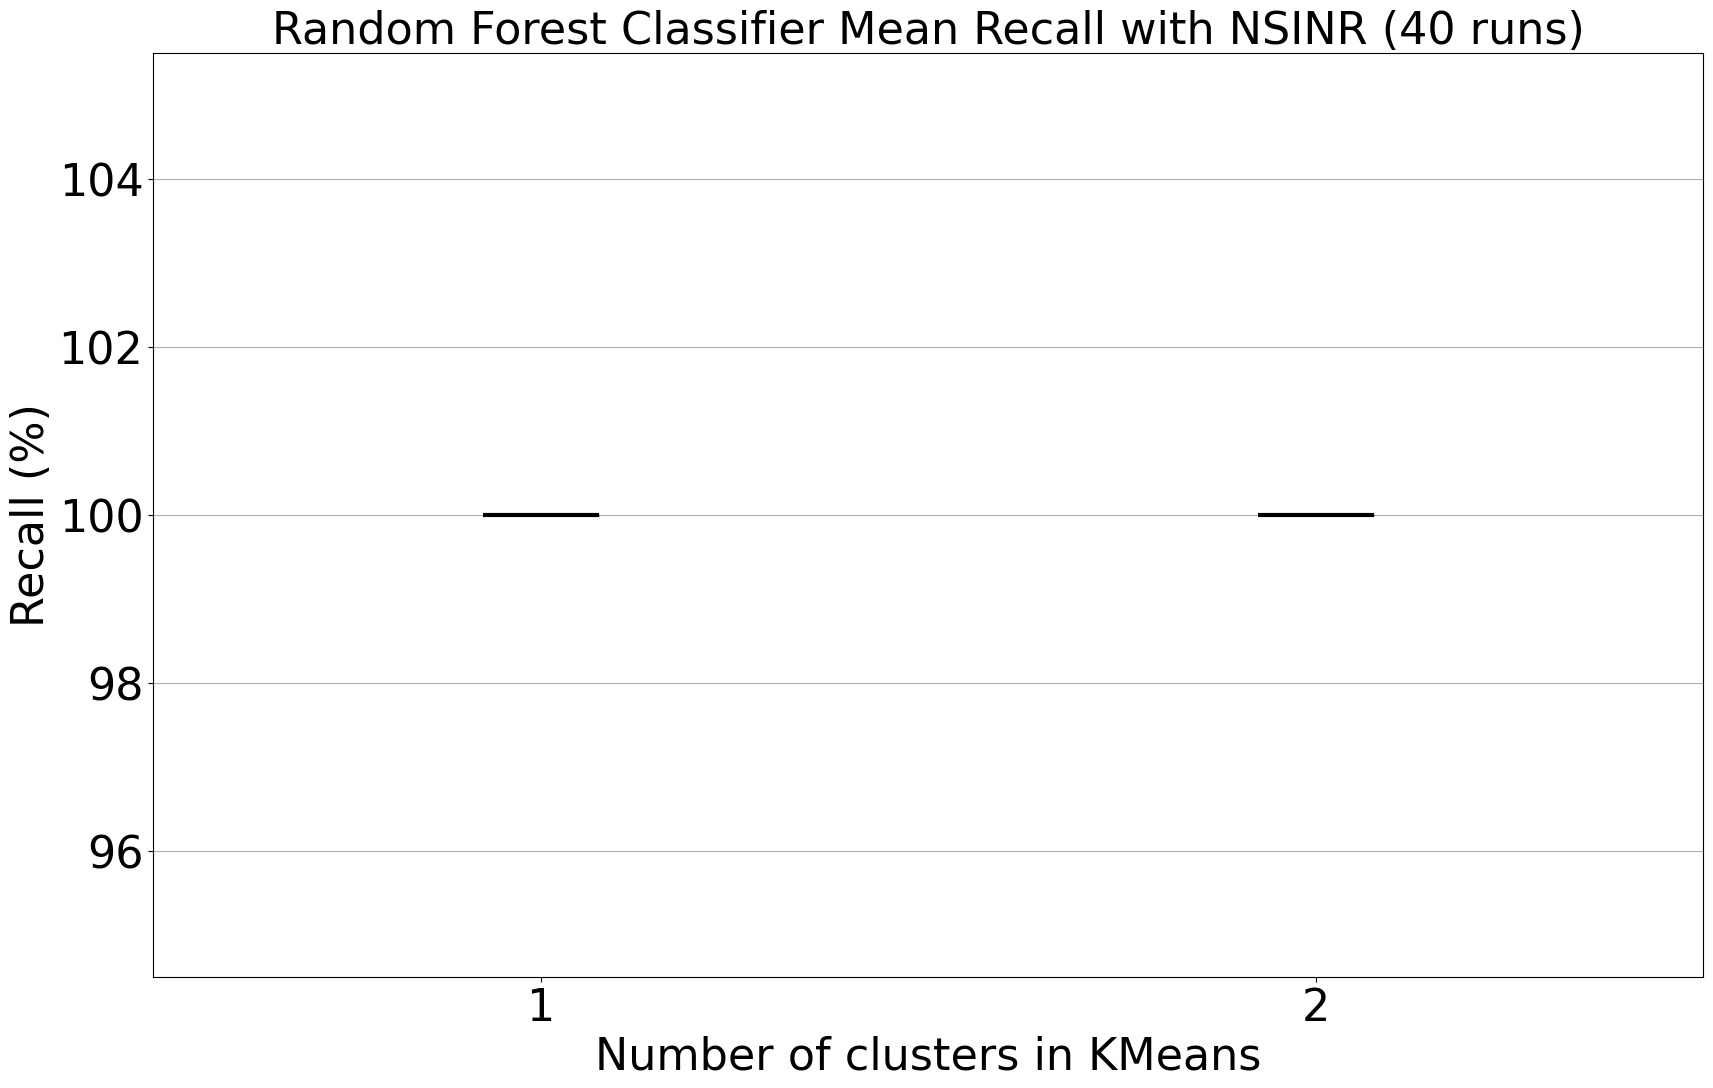

,1,2
0,[2670],"[2212, 458]"


In [2]:

import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from scripts.weighted_coverage import create_point_matrix
from sklearn.ensemble import RandomForestClassifier
from scripts.clustering import train_kmeans

rf_param = RF_PARAM.NSINR
operator_choice = np.array([1, 10, 88])
unique_npcis = extract_unique_npcis(df, operator_choice)

# experiment setup
n_runs = 1
max_clusters = 2
cluster_range = range(1, max_clusters + 1)

accuracy_dict = {n_clusters: [] for n_clusters in cluster_range}
recall_dict = {n_clusters: [] for n_clusters in cluster_range}
cluster_size_dict = {n_clusters: [] for n_clusters in cluster_range}

for run in range(n_runs):
    print(f'\r🔄 {run + 1}/{n_runs} runs', end='')
    for n_clusters in range(1, max_clusters + 1):
        df_tmp = df.copy()
        kMeans, cluster_labels = train_kmeans(df_tmp, n_clusters, random_seeds[n_clusters])
        df_tmp['cluster'] = cluster_labels

        cluster_size_dict[n_clusters].append(
            df_tmp["cluster"].value_counts().values.astype(int)
        )

        test_mask = np.random.rand(len(df_tmp)) <= 0.3
        tp = df_tmp[test_mask].copy()
        rp = df_tmp[~test_mask].copy()

        m_tp, _ = create_point_matrix(tp, unique_npcis, rf_param)
        m_rp, _ = create_point_matrix(rp, unique_npcis, rf_param)

        rf_model = RandomForestClassifier(n_estimators=100, random_state=random_seeds[n_clusters])
        rf_model.fit(m_rp, rp['cluster'])

        tp['predicted'] = rf_model.predict(m_tp)

        # get the accuracy
        accuracy = accuracy_score(tp['cluster'], tp['predicted'])
        accuracy_dict[n_clusters].append(accuracy * 100)

        # get the average recall
        report = classification_report(tp['cluster'], tp['predicted'], output_dict=True)
        recall_values = {label: metrics['recall'] for label, metrics in report.items() if label != 'accuracy'}
        recall_dict[n_clusters].append(sum(recall_values.values()) / len(recall_values) * 100)

print(f'\r✅ ')

accuracy_df = pd.DataFrame(accuracy_dict)
recall_df = pd.DataFrame(recall_dict)
cluster_size_df = pd.DataFrame(cluster_size_dict)

from scripts.plotting import make_boxplot

make_boxplot(
    accuracy_df,
    'Random Forest Classifier Accuracy with NSINR (40 runs)',
    'Number of clusters in KMeans',
    'Accuracy (%)',
    'Forestgreen'
)
make_boxplot(
    recall_df,
    'Random Forest Classifier Mean Recall with NSINR (40 runs)',
    'Number of clusters in KMeans',
    'Recall (%)',
    'Tomato'
)
# make_boxplot(
#     cluster_size_df,
#     'Random Forest Classifier Mean Cluster Size',
#     'Number of clusters in KMeans',
#     'Cluster size',
#     'aquamarine'
# )

cluster_size_df

In [3]:
df['cluster'].value_counts()

KeyError: 'cluster'

In [ ]:


make_boxplot(
    df=cluster_size_df,
    title="Distribution of cluster sizes in K-Means",
    x_label='Number of clusters',
    y_label='Cluster size',
    color='lightblue'
)
# Transform the data into a long-form DataFrame
# cluster_sizes = []
# for num_clusters, cluster_list in cluster_size_df.iloc[0].items():
#     for size in cluster_list:
#         cluster_sizes.append({'Number of Clusters': num_clusters, 'Cluster Size': size})
# 
# long_df = pd.DataFrame(cluster_sizes)
# 
# # Plot using Seaborn
# plt.figure(figsize=(12, 8))
# sns.boxplot(x='Number of Clusters', y='Cluster Size', data=long_df)
# 
# # Customize the plot
# plt.title('Distribution of Cluster Sizes for Different Numbers of Clusters')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Cluster Size')
# plt.xticks(rotation=45)
# plt.grid(True)
# 
# # Show the plot
# plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

errors = pd.read_csv('errors-kmeans-rf-k2.csv')
stdds = {}
# Calculate standard deviation for each column
for col in cluster_size_df.columns:
    # Flatten the list of cluster sizes in each column
    sizes = [size for sublist in cluster_size_df[col] for size in sublist]
    # Calculate the standard deviation
    std = np.std(sizes, ddof=1)  # Using ddof=1 for sample standard deviation
    stdds[f'{col}'] = std

errors.drop(columns=['Unnamed: 0'], inplace=True)

combined = []
errors
for col in errors.columns:
    mean = errors[col].mean()
    combined.append((col, mean, stdds[col]))

combined_df = pd.DataFrame(combined, columns=['k-val', 'mean error', 'stdd'])
combined_df = combined_df.drop(index=0)

# Plotting
plt.figure(figsize=(10, 6))

plt.scatter(combined_df['stdd'], combined_df['mean error'], marker='o')

# Adding labels and title
plt.title('Scatter Plot of Mean Error vs. Std of cluster sizes')
plt.xlabel('Standard deviation of cluster sizes')
plt.ylabel('Mean Error')
plt.grid(True)

# Show the plot
plt.show()
